# Portfolio Metrics

*Note:* The `massive` library was installed with the Python 3.13.3 kernel, so use that one.

In [92]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import contextlib
import io

In [66]:
from copulae import GaussianCopula, StudentCopula

In [126]:
tickers = [
    "SPY", "QQQ", "DFAI", "META", "JPM", "MSFT",
    "AMZN", "NFLX", "GOOG", "ORCL", 
    "GLD", "COST", "VDC", "XLU"
]

years = 5
end_date = date.today()
start_date = end_date - timedelta(days=years * 365)

In [127]:
def get_daily_bars(symbols, start_date, end_date):
    """
    Fetch daily OHLCV data from Yahoo Finance using yfinance.

    Returns:
        data: long DataFrame with columns:
              symbol, open, high, low, close, adj_close, volume
        close_prices: wide DataFrame of close prices by symbol
    """

    raw = yf.download(
        tickers=symbols,
        start=start_date.isoformat(),
        end=end_date.isoformat(),
        interval="1d",
        auto_adjust=False,
        group_by="ticker",
        progress=True,
        threads=True
    )

    all_dfs = []

    for symbol in symbols:
        try:
            df = raw[symbol].copy()
        except KeyError:
            print(f"No data returned for {symbol}")
            continue

        if df.empty:
            print(f"No data returned for {symbol}")
            continue

        df = df.rename(columns={
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Adj Close": "adj_close",
            "Volume": "volume"
        })

        df["symbol"] = symbol
        df.index.name = "timestamp"

        df = df[["symbol", "open", "high", "low", "close", "adj_close", "volume"]]
        all_dfs.append(df)

    data = pd.concat(all_dfs).sort_index()

    close_prices = data.pivot_table(
        values="close",
        index=data.index,
        columns="symbol"
    )

    return data, close_prices


data, close_prices = get_daily_bars(tickers, start_date, end_date)

print(close_prices.tail())

[*********************100%***********************]  14 of 14 completed

symbol            AMZN        COST       DFAI         GLD        GOOG  \
timestamp                                                               
2026-06-25  227.009995  942.239990  41.060001  369.459991  342.190002   
2026-06-26  232.690002  952.539978  40.900002  373.630005  334.690002   
2026-06-29  240.139999  946.679993  41.139999  368.579987  351.279999   
2026-06-30  238.339996  935.469971  41.250000  368.380005  353.329987   
2026-07-01  241.699997  924.669983  41.090000  370.600006  357.890015   

symbol             JPM        META        MSFT       NFLX        ORCL  \
timestamp                                                               
2026-06-25  335.119995  542.869995  352.829987  70.900002  152.460007   
2026-06-26  329.049988  550.250000  372.970001  73.809998  148.529999   
2026-06-29  329.390015  562.599976  368.570007  73.779999  147.759995   
2026-06-30  327.329987  563.289978  373.019989  71.400002  146.550003   
2026-07-01  334.070007  612.909973  384.279999  74

In [128]:
def max_drawdown(prices):
    roll_max = prices.cummax()
    drawdown = prices / roll_max - 1
    return drawdown.min()

In [131]:
def copula_num_params(cop, family_name, dim):
    family_name = family_name.lower()

    if family_name == "gaussian":
        return dim * (dim - 1) // 2

    elif family_name == "student_t":
        return len(cop.params.rho) + 1   # pairwise correlations and degrees of freedom

    elif family_name in ["clayton", "gumbel", "frank"]:
        return 1

    else:
        return np.asarray(cop.params).size

In [132]:
def extract_params(cop, name):
    name = name.lower()

    if name == "student_t":
        return {
            "df": float(cop.params.df),
            "rho": np.asarray(cop.params.rho).copy()
        }

    elif name == "gaussian":
        return {
            "rho": np.asarray(cop.params).copy()
        }

    else:
        return cop.params

In [104]:
def num_params(cop, name):
            name = name.lower()
            if name == "gaussian":
                return d * (d - 1) // 2
            elif name == "student_t":
                return len(cop.params.rho) + 1
            else:
                return np.asarray(cop.params).size

In [159]:
class Portfolio:
    '''
    Fields:
        self.tickers is a list of security tickers in the portfolio
        self.weights is a dictionary with ticker keys and portfolio weight values
        self.data is a DataFrame of price data for the securities in the portfolio

    Dependencies:
        numpy as np
        pandas as pd
        pyvinecopulib as pv
    '''

    def __init__(self, tickers, df, weights={}):
        self.tickers = tickers
        self.weights = weights
        self.data = df


    def holding_data(self, holding):
        df = self.data
        if holding != 'all':
            df = df[holding]
        return df


    def returns(self, holding='all', log=True):
        '''
        The daily log returns (i.e. log(P[t]/P[t-1]) = log(P[t]) - log(P[t-1]) )
        or the daily ordinary returns if log=False (i.e. P[t]/P[t-1] - 1 ).
        '''
        df = self.holding_data(holding)
        if log:
            return np.log(df).diff().dropna()
        else:
            return df.pct_change().dropna()
        

    def uni_summary(self, holding='all', log=True, tail=0.05):
        '''
        Returns a univariate summary of the returns of each security (individually), including:
            - the annualized mean and volatility, 
            - the skew and excess kurtosis, and 
            - some tail risk metrics (VaR, ES/CVaR, MaxDD).
        '''
        df = self.returns(holding=holding, log=log)
        means = df.mean()

        d = {}
        if log:
            d['Mean (Ann.)'] = means * 252
        else: 
            d['Mean (Ann.)'] = (1 + means)**252 - 1 
            # Note: this is equivalent to the expression in the log=True case
            #       although we break up the cases to take advantage of the
            #       simplified formula for log=True.
        d['Volatility (Ann.)'] = df.std() * np.sqrt(252)
        d['Skew'] = df.skew()
        d['Kurtosis (Excess)'] = df.kurtosis()
        d[f'VaR({tail*100:.1f}%)'] = df.quantile(tail) 
        d[f'ES({tail*100:.1f}%)'] = df.apply(lambda col: col[col <= col.quantile(tail)].mean())
        d[f'MaxDD'] = max_drawdown( (1+df).cumprod() )

        return pd.DataFrame(d).T
    

    def dependence(self, type="corr", holding="all", log=True, tail=0.05):
        """
        Dependence measures between return series.

        type options:
            - "corr": Pearson correlation
            - "cov": covariance
            - "spearman": rank correlation
            - "kendall": Kendall's tau
            - "lower_tail": empirical lower tail dependence
            - "upper_tail": empirical upper tail dependence
            - "all": dictionary of several dependence measures
        """

        df = self.returns(holding=holding, log=log).dropna()

        if type == "corr":
            return df.corr(method="pearson")
        elif type == "cov":
            return df.cov()
        elif type == "spearman":
            return df.corr(method="spearman")
        elif type == "kendall":
            return df.corr(method="kendall")
        elif type in ["lower_tail", "upper_tail"]:
            ranks = df.rank(method="average") / (len(df) + 1)
            out = pd.DataFrame(
                np.eye(len(df.columns)),
                index=df.columns,
                columns=df.columns
            )
            for i in df.columns:
                for j in df.columns:
                    if i == j:
                        continue
                    if type == "lower_tail":
                        # P(U_i <= q | U_j <= q)
                        numerator = ((ranks[i] <= tail) & (ranks[j] <= tail)).mean()
                        denominator = (ranks[j] <= tail).mean()
                    else:
                        # P(U_i >= 1-q | U_j >= 1-q)
                        numerator = ((ranks[i] >= 1 - tail) & (ranks[j] >= 1 - tail)).mean()
                        denominator = (ranks[j] >= 1 - tail).mean()
                    out.loc[i, j] = numerator / denominator if denominator > 0 else np.nan
            return out
        elif type == "all":
            return {
                "pearson_corr": df.corr(method="pearson"),
                "spearman_corr": df.corr(method="spearman"),
                "kendall_tau": df.corr(method="kendall"),
                "covariance": df.cov(),
                f"lower_tail_{tail}": self.dependence(
                    type="lower_tail", holding=holding, log=log, tail=tail
                ),
                f"upper_tail_{tail}": self.dependence(
                    type="upper_tail", holding=holding, log=log, tail=tail
                )
            }
        else:
            raise ValueError(
                "type argument must be one of: 'corr', 'cov', 'spearman', 'kendall', "
                "'lower_tail', 'upper_tail', or 'all'"
            )
        
    def margin_fit(self, holding="all", log=True): 
        """
        Fit marginal distributions to individual security returns. 

        Families:
            - Normal
            - Student-t
            - Laplace (Double Exponential)
            - GEV (Generalized Extreme Value)
        """
        
        df = self.returns(holding=holding, log=log).dropna()

        if df.shape[1] < 1:
            raise ValueError("Need at least one asset to fit marginals.")

        results = []

        for col in df.columns:
            series = df[col].dropna()
            n = len(series)

            # Fit Normal distribution
            mu, sigma = series.mean(), series.std()
            ll_normal = np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((series - mu)**2) / (2 * sigma**2))
            aic_normal = -2 * ll_normal + 2 * 2  # 2 parameters: mu and sigma
            bic_normal = -2 * ll_normal + np.log(n) * 2

            # Fit Student-t distribution
            from scipy.stats import t 
            params_t = t.fit(series)
            ll_t = np.sum(t.logpdf(series, *params_t))
            aic_t = -2 * ll_t + 2 * len(params_t)
            bic_t = -2 * ll_t + np.log(n) * len(params_t)

            # Fit Laplace distribution
            from scipy.stats import laplace
            params_laplace = laplace.fit(series)
            ll_laplace = np.sum(laplace.logpdf(series, *params_laplace))
            aic_laplace = -2 * ll_laplace + 2 *len(params_laplace)
            bic_laplace = -2 * ll_laplace + np.log(n) * len(params_laplace)

            # Fit GEV distribution
            from scipy.stats import genextreme
            params_gev = genextreme.fit(series)
            ll_gev = np.sum(genextreme.logpdf(series, *params_gev))
            aic_gev = -2 * ll_gev + 2 * len(params_gev)
            bic_gev = -2 * ll_gev + np.log(n) * len(params_gev) 

            results.append({
                "Asset": col,
                "Normal": {"mu": mu, "sigma": sigma, "loglik": ll_normal, "aic": aic_normal, "bic": bic_normal},
                "Student-t": {"params": params_t, "loglik": ll_t, "aic": aic_t, "bic": bic_t},
                "Laplace": {"params": params_laplace, "loglik": ll_laplace, "aic": aic_laplace, "bic": bic_laplace}, 
                "GEV": {"params": params_gev, "loglik": ll_gev, "aic": aic_gev, "bic": bic_gev},
                "Best-Fit-AIC": None,
                "Best-Fit-BIC": None
            })

            results[-1]["Best-Fit-AIC"] = min(["Normal", "Student-t", "Laplace", "GEV"], key=lambda x: results[-1][x]["aic"])
            results[-1]["Best-Fit-BIC"] = min(["Normal", "Student-t", "Laplace", "GEV"], key=lambda x: results[-1][x]["bic"])

        return pd.DataFrame(results)
    
    def copula_fit(self, holding="all", log=True, criterion="bic"):
        """
        Fit a copula to portfolio returns.

        Families:
            - Gaussian
            - Student-t
        """

        df = self.returns(holding=holding, log=log).dropna()

        if df.shape[1] < 2:
            raise ValueError("Need at least two assets to fit a copula.")

        criterion = criterion.lower()
        if criterion not in ["aic", "bic"]:
            raise ValueError("criterion must be 'aic' or 'bic'.")

        d = df.shape[1]

        models = {
            "gaussian": GaussianCopula(dim=d),
            "student_t": StudentCopula(dim=d)
        }

        results = []

        for name, cop in models.items():
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    cop.fit(df, to_pobs=True)

                u = cop.pobs(df)

                ll = cop.log_lik(u)
                k = num_params(cop, name)
                n = len(df)

                aic = -2 * ll + 2 * k
                bic = -2 * ll + np.log(n) * k

                params = extract_params(cop, name)

                results.append({
                    "family": name,
                    "loglik": ll,
                    "n_params": k,
                    "aic": aic,
                    "bic": bic,
                    "params": params,
                    "model": cop,
                    "error": None
                })

            except Exception as e:
                results.append({
                    "family": name,
                    "loglik": np.nan,
                    "n_params": np.nan,
                    "aic": np.nan,
                    "bic": np.nan,
                    "params": None,
                    "model": None,
                    "error": repr(e)
                })

        summary = (
            pd.DataFrame(results)
            .drop(columns=["model"], errors="ignore")
            .sort_values(criterion, na_position="last")
            .reset_index(drop=True)
        )

        valid = [r for r in results if r["model"] is not None]

        if not valid:
            raise RuntimeError("No copula models successfully fit.")

        best = min(valid, key=lambda r: r[criterion])

        return {
            "summary": summary,
            "best_family": best["family"],
            "best_params": best["params"],
            "best_model": best["model"],
            "all_results": results,
            "assets": list(df.columns),
            "n_obs": len(df),
            "dimension": d,
            "criterion": criterion
        }

        



## Testing out the `Portfolio` class (*without* weights)

In [160]:
# create instance of Portfolio class
p = Portfolio(tickers=tickers, df=close_prices)

In [161]:
summary = p.uni_summary()
summary

symbol,AMZN,COST,DFAI,GLD,GOOG,JPM,META,MSFT,NFLX,ORCL,QQQ,SPY,VDC,XLU
Mean (Ann.),0.055134,0.169240,0.068687,0.159099,0.204187,0.156642,0.111181,0.065410,0.063325,0.108597,0.140849,0.109461,0.044191,0.066680
Volatility (Ann.),0.356899,0.228798,0.160747,0.183971,0.313700,0.245556,0.447908,0.270181,0.448269,0.414923,0.227221,0.171934,0.132821,0.173330
Skew,-0.097723,-0.821939,0.022515,-0.879454,0.003605,-0.063053,-1.125427,-0.075954,-3.066870,1.337392,0.031418,0.147696,-0.455202,-0.317792
Kurtosis (Excess),4.782233,8.731673,4.152956,8.535132,3.309595,4.699368,24.547873,3.556341,50.190501,20.075615,4.460298,7.885659,4.230144,1.782642
VaR(5.0%),-0.033887,-0.021597,-0.015821,-0.017881,-0.029174,-0.024216,-0.040770,-0.027327,-0.035792,-0.039048,-0.023333,-0.016852,-0.013258,-0.017663
ES(5.0%),-0.052018,-0.033828,-0.022365,-0.027317,-0.043916,-0.036592,-0.063949,-0.039021,-0.062770,-0.058990,-0.033124,-0.025024,-0.018771,-0.024995
MaxDD,-0.618939,-0.326488,-0.308576,-0.281145,-0.482305,-0.429732,-0.817506,-0.410032,-0.810447,-0.619986,-0.390297,-0.270605,-0.183998,-0.296246


<Axes: title={'center': 'Individual Returns (Daily)'}, xlabel='Date', ylabel='Return (%)'>

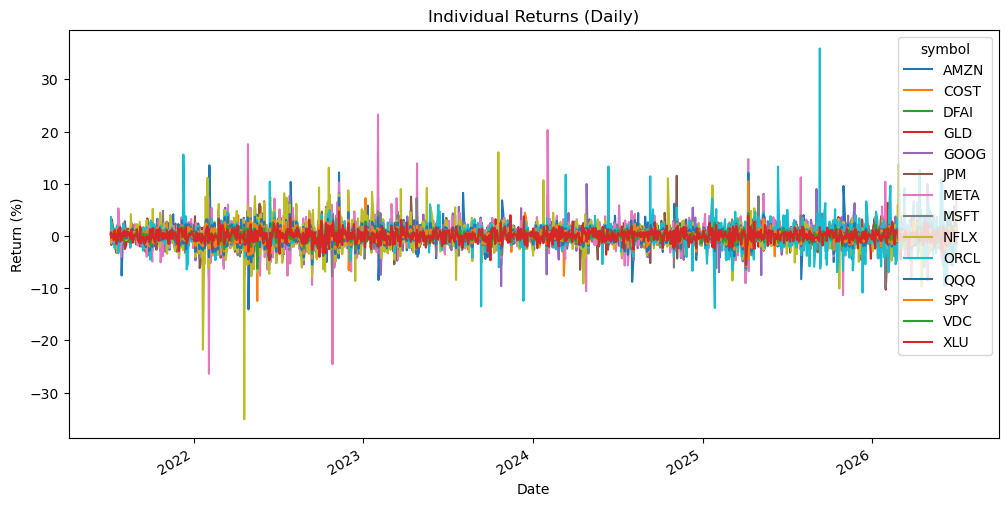

In [153]:
(p.returns(holding='all', log=False)*100).plot(
    title="Individual Returns (Daily)",
    xlabel="Date",
    ylabel="Return (%)",
    figsize=(12, 6)
)

<Axes: title={'center': 'Individual Returns (Cumulative)'}, xlabel='Date', ylabel='Cumulative Return (%)'>

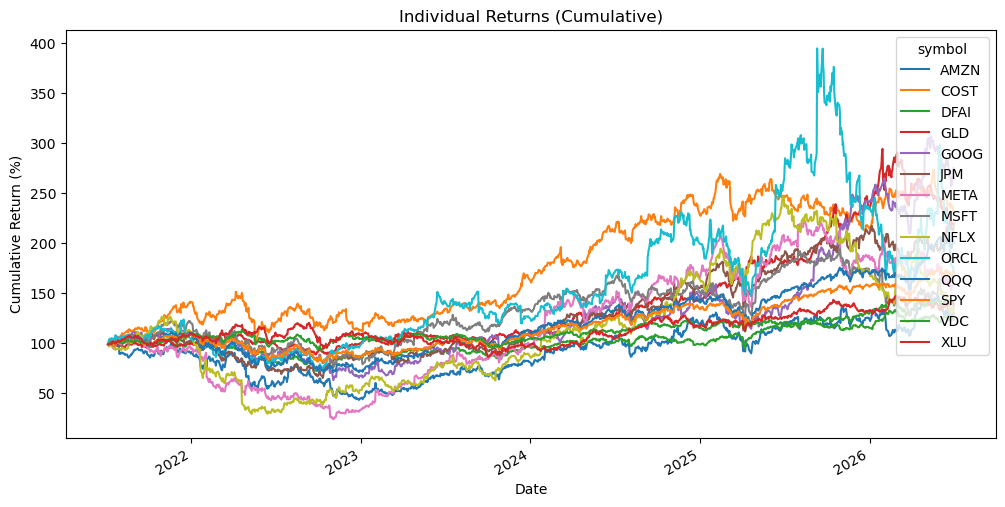

In [154]:
p.data.apply(lambda x: 100*x/x.iloc[0]-1).plot(
    title="Individual Returns (Cumulative)",
    xlabel="Date",
    ylabel="Cumulative Return (%)",
    figsize=(12, 6)
)

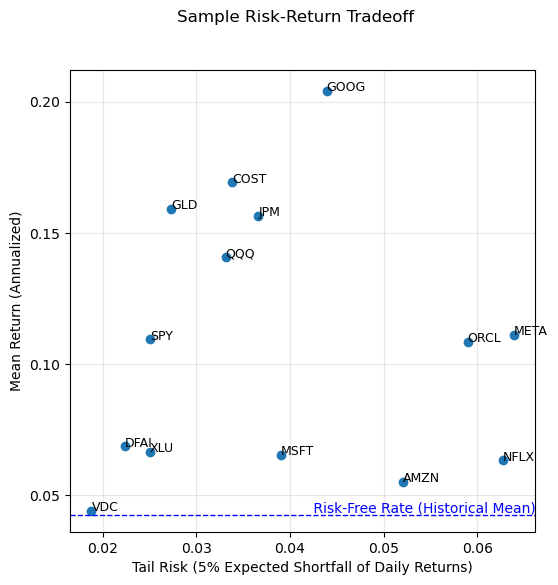

In [175]:
## make this plot a method in the class
fig, ax = plt.subplots(figsize=(6, 6))
x = -summary.loc['ES(5.0%)'] 
y = summary.loc['Mean (Ann.)']
ax.scatter(x=x, y=y)
texts = []
for t in summary.columns:
    texts.append(ax.text(x[t], y[t], t, fontsize=9))
ax.set_xlabel('Tail Risk (5% Expected Shortfall of Daily Returns)') ; ax.set_ylabel('Mean Return (Annualized)')
fig.suptitle(f'Sample Risk-Return Tradeoff')
ax.grid(True, alpha=0.3)
rf = 0.0425 # historical avg risk-free rate (10yr treasury YTM)
ax.axhline(y=rf, color='blue', linestyle='--', linewidth=1)
ax.text(
    ax.get_xlim()[1],
    rf,
    " Risk-Free Rate (Historical Mean)",
    color="blue",
    va="bottom",
    ha="right",
    fontsize=10
)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.05))

plt.show()


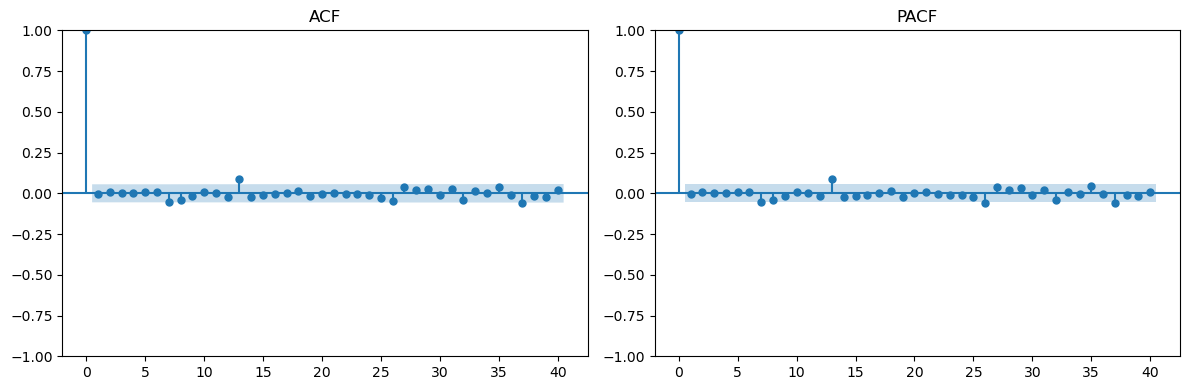

In [116]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Plot ACF and PACF for returns
log_returns = p.returns(log=True).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(log_returns.iloc[:, 0], lags=40, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(log_returns.iloc[:, 0], lags=40, ax=axes[1])
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

In [177]:
round(p.dependence(), 2)

symbol,AMZN,COST,DFAI,GLD,GOOG,JPM,META,MSFT,NFLX,ORCL,QQQ,SPY,VDC,XLU
symbol,,,,,,,,,,,,,,
AMZN,1.00,0.39,0.50,0.06,0.62,0.36,0.59,0.62,0.45,0.32,0.76,0.71,0.27,0.19
COST,0.39,1.00,0.37,0.05,0.33,0.26,0.32,0.40,0.30,0.18,0.51,0.53,0.65,0.32
DFAI,0.50,0.37,1.00,0.34,0.49,0.56,0.44,0.46,0.33,0.34,0.72,0.80,0.50,0.43
GLD,0.06,0.05,0.34,1.00,0.11,0.04,0.06,0.07,0.07,0.08,0.14,0.14,0.10,0.21
GOOG,0.62,0.33,0.49,0.11,1.00,0.32,0.53,0.57,0.35,0.31,0.72,0.68,0.26,0.19
JPM,0.36,0.26,0.56,0.04,0.32,1.00,0.30,0.30,0.23,0.24,0.48,0.62,0.36,0.30
META,0.59,0.32,0.44,0.06,0.53,0.30,1.00,0.54,0.42,0.27,0.66,0.61,0.21,0.12
MSFT,0.62,0.40,0.46,0.07,0.57,0.30,0.54,1.00,0.41,0.46,0.75,0.71,0.29,0.20
NFLX,0.45,0.30,0.33,0.07,0.35,0.23,0.42,0.41,1.00,0.21,0.51,0.46,0.19,0.12


In [179]:
fit = p.copula_fit(criterion="bic") # note: this can take a couple minutes for the student-t copula

In [180]:
fit["summary"]

,family,loglik,n_params,aic,bic,params,error
0,student_t,6946.773550,92,-13709.547099,-13237.357325,"{'df': 9.421906977178853, 'rho': [0.3986615466...",None
1,gaussian,6515.690743,6,-13019.381485,-12988.586500,"{'rho': [0.38647864034133156, 0.50352323762112...",None


From Sklar's theorem, for a random $d$-vector $X=(X_1,\dots,X_d)^\top$ with joint CDF $F$, copula $C$, and margins $F_i$ for $X_i$, the CDF can be decomposed into
$$
F(x) = C\Big(F_1(x_1),\dots,F_d(x_d) \Big) \quad \forall x\in\mathbb{R}^d
$$
and hence the density $f$ satisfies
$$
f(x) = {\small \frac{d}{dx}} F(x) =  c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) \quad \forall x\in\mathbb{R}^d
$$
where $c$ is the density of the copula, i.e., 
$$ 
c(u) = {\small \frac{\partial^d}{\partial u_1 \cdots \partial u_d }} C(u)
$$

The $t$ copula with $\nu>0$ degrees of freedom and correlation matrix $P\in\mathbb{R}^{d\times d}$ can be represented by
$$
C^t_{\nu, P}(u) = \int_{-\infty}^{t^{-1}_\nu(u_1)} \cdots \int_{-\infty}^{t^{-1}_\nu(u_d)} \frac{\Gamma(\frac{\nu + d}{2})}{\Gamma(\nu/2) \sqrt{(\pi\nu)^d \det P}} 
\Big(1 + \frac{1}{\nu} x^\top P^{-1} x \Big)^{-(\nu + d)/{2}} dx \quad\quad \forall u\in(0,1)^d
$$
where $t^{-1}_\nu$ is the quantile function of a univariate $t_{(\nu)}$ distribution. 

Source: ("The $t$ Copula and Related Copulas") https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/303eb11b4d617b79c1257b0800744575/$FILE/t%20copula%20demarta%20mcneil.pdf

Let $R=w^\top X$ be the portfolio return random variable, where $w\in[0,1]^d$ is the vector of (fixed) portfolio weights.

The CDF is of $R$ is then 
$$
\begin{aligned}
G(r) &= \mathbb{P}(R\leq r) = \int_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x)dx = \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x) dx \\
&= \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) dx
\end{aligned}
$$


In [181]:
fit["best_family"] 

'student_t'

In [186]:
student_params = fit["summary"].loc[fit["summary"]["family"] == "student_t", "params"].iloc[0]
student_params

{'df': 9.421906977178853,
 'rho': array([0.39866155, 0.51897844, 0.07193801, 0.66065991, 0.34843045,
        0.64165546, 0.66863036, 0.52657431, 0.43078668, 0.7848042 ,
        0.73301784, 0.25851071, 0.17564251, 0.36631001, 0.04524664,
        0.34010414, 0.24302706, 0.38256079, 0.44043246, 0.38333645,
        0.26307386, 0.51458985, 0.53226   , 0.63050144, 0.31943836,
        0.32955666, 0.50580435, 0.54709997, 0.51443581, 0.49873185,
        0.40394977, 0.41036132, 0.69841737, 0.78517792, 0.47505596,
        0.3933951 , 0.11257126, 0.02111402, 0.07250278, 0.07102286,
        0.08809674, 0.07916314, 0.11148741, 0.12109064, 0.09709512,
        0.19043903, 0.32382295, 0.61334124, 0.64245755, 0.43871288,
        0.39861384, 0.75178212, 0.70696964, 0.23677127, 0.18029741,
        0.3374378 , 0.31866007, 0.26311108, 0.29354694, 0.45705221,
        0.60888375, 0.35941381, 0.29848244, 0.63689432, 0.53845619,
        0.40197142, 0.74188612, 0.68903552, 0.22920481, 0.13546681,
        0.51687

In [191]:
dim = p.data.shape[1]

df = float(student_params["df"])
rho = np.asarray(student_params["rho"], dtype=float).ravel()

student_t_copula = StudentCopula(dim=dim)
student_t_copula.params = np.concatenate(([df], rho))

def student_t_copula_pdf(u):
    u = np.asarray(u, dtype=float)
    if u.ndim == 1:
        u = u.reshape(1, -1)
    return student_t_copula.pdf(u)


def student_t_copula_cdf(u):
    u = np.asarray(u, dtype=float)
    if u.ndim == 1:
        u = u.reshape(1, -1)
    return student_t_copula.cdf(u)

In [193]:
margins = p.margin_fit()

In [194]:
margins

,Asset,Normal,Student-t,Laplace,GEV,Best-Fit-AIC,Best-Fit-BIC
0,AMZN,"{'mu': 0.00021878576898424972, 'sigma': 0.0224...","{'params': (4.265120519445272, 0.0004608453226...","{'params': (0.0003428575146782187, 0.016144049...","{'params': (1.339578966290028, -0.033508391661...",Student-t,Student-t
1,COST,"{'mu': 0.0006715866271736607, 'sigma': 0.01441...","{'params': (4.043465133294979, 0.0010576375849...","{'params': (0.0009685587301015985, 0.010206808...","{'params': (0.2274090099553745, -0.00490713661...",Student-t,Student-t
2,DFAI,"{'mu': 0.00027256685427485265, 'sigma': 0.0101...","{'params': (5.098691857972697, 0.0004011275912...","{'params': (0.0006761483340425034, 0.007457502...","{'params': (0.1709570413036755, 0.000761924765...",Student-t,Student-t
3,GLD,"{'mu': 0.000631346125580862, 'sigma': 0.011589...","{'params': (3.7975333409222336, 0.000865218799...","{'params': (0.0007061061978976824, 0.008166281...","{'params': (1.4025314632373655, -0.00899234502...",Student-t,Student-t
4,GOOG,"{'mu': 0.0008102670838549706, 'sigma': 0.01976...","{'params': (4.3557107828346275, 0.000962353370...","{'params': (0.0013180105706394052, 0.014345330...","{'params': (0.1892856558742811, -0.00704920385...",Student-t,Student-t
5,JPM,"{'mu': 0.0006215946278371913, 'sigma': 0.01546...","{'params': (4.0313020682070775, 0.001067240814...","{'params': (0.001024158081175841, 0.0110746845...","{'params': (1.3238448190632774, -0.01758426583...",Student-t,Student-t
6,META,"{'mu': 0.0004411928376154182, 'sigma': 0.02821...","{'params': (3.0903422534297986, 0.000772415478...","{'params': (0.0007487313381449034, 0.018024410...","{'params': (1.335967994820555, -0.005373936759...",Student-t,Student-t
7,MSFT,"{'mu': 0.0002595639724992791, 'sigma': 0.01701...","{'params': (4.182016720095632, 0.0005074494449...","{'params': (0.0003956465037200374, 0.012267618...","{'params': (1.3439262399121716, -0.01265158300...",Laplace,Laplace
8,NFLX,"{'mu': 0.0002512882547473961, 'sigma': 0.02823...","{'params': (3.041654205183593, 0.0003793089521...","{'params': (0.00011859647029499598, 0.01766948...","{'params': (0.2611871613859127, -0.01047912901...",Student-t,Student-t
9,ORCL,"{'mu': 0.0004309408775248699, 'sigma': 0.02613...","{'params': (2.662973871163283, 0.0004500075426...","{'params': (0.0007861369530099971, 0.016726876...","{'params': (0.08844833221348103, -0.0108910048...",Student-t,Student-t


### `SimReturnsVector()`
1. Simulate $V\sim C$ via $V_i=C^{-1}(U_i)$ for $i=1,\dots,d$ where $U\overset{iid}{\sim}\text{Unif}(0,1)$
2. Simulate and return $X\sim F$ via $X_i=F_i^{-1}(V_i)$ for $i=1,\dots,d$

### `SimPortfolioReturn()`
1. Simulate $X=$`SimReturnsVector()`
2. Return $R=w^\top X$

In [ ]:
# this is what getting marginal quantile functions looks like
from scipy.stats import norm, t, laplace, genextreme

params = margins.loc[margins["Asset"] == "SPY", "Student-t"].iloc[0]["params"]
qt = lambda x: t.ppf(x, df=params["df"], loc=params["loc"], scale=params["scale"])


## Next Features for this Project
CAN DO NOW:
- fit margins to portfolio (already strated sketch of this method)
    - use margins + copula to (statically) estimate things like VaR and ES *for the portfolio random vector* $y=x^\top w$
    - TODO for this:
        - make joint_pdf() and joint_cdf method which creates the joint PDF and CDF using the margins and copula 
        - make risk_measures() method which uses the joint density to output key risk measures like ES, VaR, MaxDD, etc.
            - this will rely on portfolio weights (as opposed to individual security risks as prev done)
            - UP TO HERE COULD STAND ALONE AS A PARAMETRIC EQUITY RISK ENGINE BTW (?)

AFTER FINISHING MIT FACTOR MODELING STUDYING:
- linear factor models
    - understanding portfolio risks/drivers
    - parameter reduction for covariance estimation
    - stress testing (e.g. VaR / ES under different macro shock/equity market scenarios)
- portfolio optimization
    - Mean-Var optimiziation (with different covariance matrix estimates incl. the factor model est.)
    - Mean-ES optimization
- volatility models
    - GARCH (+ dynamic mean return model -- look for examples online of what ppl use / look at Mike M's PhD paper)
    - Stochastic Vol model (Heston) - which also models returns as a whole
    - VaR / ES forecasting from the model
- genAI feature(s): 
    - RAG over market news for explaining recent portfolio movements

SEPARATE PROJECT:
- market bubble / market crash predictor
    - can try a variety of methods and/or an ensemble of them
        - the graph theory one or whatever from algebraic continuation channel,
        - the XLU/SPY z-score thiing or whatever from iPhone notes on PROJECTS

### Next: do ES-based portfolio optimization (e.g. using `cvxpy`) and test out/make portfolio-wide summaries

In [ ]:
# quantities and weights of each holding
q = {
    "DFAI":43, 
    "META":2, 
    "MSFT":3, 
    "JPM":4, 
    "SCHQ":45
}
w = {k: v/sum(q.values()) for k, v in q.items()}

# tickers
my_pft = list(w.keys())

# create instance of Portfolio class
p = Portfolio(tickers=my_pft, df=close_prices, weights=w)

- Review portfolio optimization math
    - CS 335 chapter 
    - ACTSC 372 chapter 
    - CO 372

Need to use weights not quantities. Also, we have to make an assumption about dynamic rebalancing right?

### Some Plotting (make this a method)

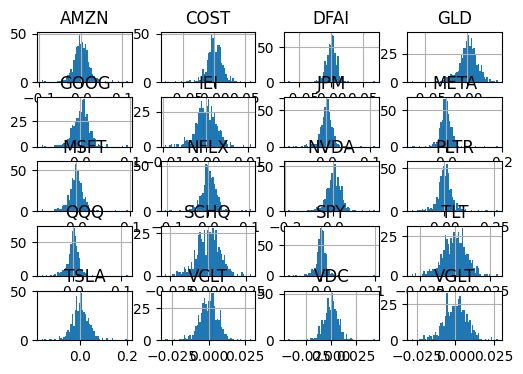

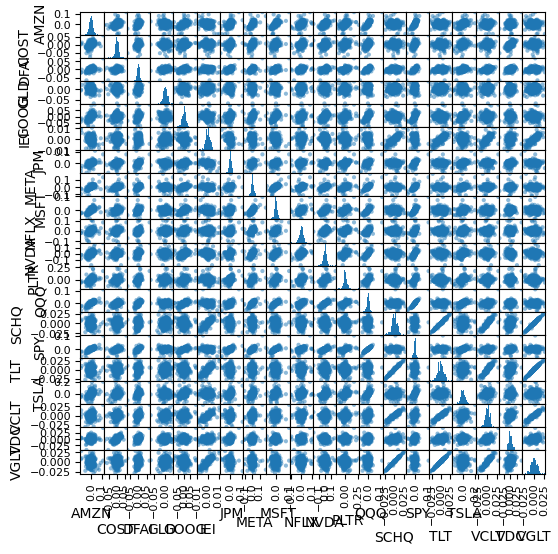

In [ ]:
# histogram of returns of each holding
log_returns = p.returns(log=True)
log_returns.hist(bins=60, figsize=(6,4))
plt.show()

# scatterplot matrix of portfolio returns
pd.plotting.scatter_matrix(log_returns, figsize=(6,6), hist_kwds={'bins':60})
plt.show()